In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print ("ALL libraries imported successfully!")

ALL libraries imported successfully!


In [7]:
# Step 2: Load the dataset
df = pd.read_excel(r"C:\Users\konin\Downloads\Ecommerce-churn\raw\E Commerce Dataset.xlsx", 
                   sheet_name="E Comm")

# Check it loaded correctly
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Shape: (5630, 20)
Rows: 5630
Columns: 20


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [11]:
print("===MISSING VALUES ===")
print(df.isnull().sum())

===MISSING VALUES ===
CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [12]:
print("Total missing cells:",df.isnull().sum().sum())

Total missing cells: 1856


In [14]:
print(df.dtypes)

CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object


In [ ]:
cols_to_fill = ['Tenure', 
                'WarehouseToHome', 
                'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 
                'CouponUsed',
                'OrderCount', 
                'DaySinceLastOrder']

for col in cols_to_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"✅ {col} filled with median: {median_val}")

print("\n=== MISSING VALUES AFTER FIX ===")
print("Total missing:", df.isnull().sum().sum())


✅ Tenure filled with median: 9.0
✅ WarehouseToHome filled with median: 14.0
✅ HourSpendOnApp filled with median: 3.0
✅ OrderAmountHikeFromlastYear filled with median: 15.0
✅ CouponUsed filled with median: 1.0
✅ OrderCount filled with median: 2.0
✅ DaySinceLastOrder filled with median: 3.0

=== MISSING VALUES AFTER FIX ===
Total missing: 0


In [21]:
print("Duplicates before:",df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:",df.duplicated().sum())
print("Final shape:",df.shape)

Duplicates before: 0
Duplicates after: 0
Final shape: (5630, 20)


In [22]:

df['ChurnStatus'] = df['Churn'].map({0: 'Active', 1: 'Churned'})


def tenure_group(t):
    if t <= 6:    return 'New (0-6 months)'
    elif t <= 12: return 'Mid (6-12 months)'
    else:         return 'Loyal (12+ months)'

df['TenureGroup'] = df['Tenure'].apply(tenure_group)


df['RiskScore'] = (
    (df['Complain'] * 2) +
    (df['SatisfactionScore'] < 3).astype(int) +
    (df['DaySinceLastOrder'] > 20).astype(int)
)

print("✅ New columns added!")
print(df[['ChurnStatus', 'TenureGroup', 'RiskScore']].head())

✅ New columns added!
  ChurnStatus        TenureGroup  RiskScore
0     Churned   New (0-6 months)          3
1     Churned  Mid (6-12 months)          2
2     Churned  Mid (6-12 months)          2
3     Churned   New (0-6 months)          0
4     Churned   New (0-6 months)          0


In [23]:

df.to_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\ecommerce_cleaned.csv", 
          index=False)

print("✅ Cleaned data saved successfully!")
print("Total rows saved:", len(df))
print("Total columns saved:", len(df.columns))
print("\nColumns in cleaned file:")
print(list(df.columns))

✅ Cleaned data saved successfully!
Total rows saved: 5630
Total columns saved: 23

Columns in cleaned file:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'ChurnStatus', 'TenureGroup', 'RiskScore']


In [4]:
# Phase 3 - Load cleaned data into MySQL
import mysql.connector
import pandas as pd

# Load cleaned CSV
df = pd.read_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\ecommerce_cleaned.csv")

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="KABHG778283",
    database="ecommerce_churn"
)

print("✅ Connected to MySQL successfully!")

# Create cursor
cursor = conn.cursor()

# Drop table if exists (fresh start)
cursor.execute("DROP TABLE IF EXISTS customers")

# Create table
cursor.execute("""
CREATE TABLE customers (
    CustomerID INT,
    Churn INT,
    Tenure FLOAT,
    PreferredLoginDevice VARCHAR(50),
    CityTier INT,
    WarehouseToHome FLOAT,
    PreferredPaymentMode VARCHAR(50),
    Gender VARCHAR(20),
    HourSpendOnApp FLOAT,
    NumberOfDeviceRegistered INT,
    PreferedOrderCat VARCHAR(50),
    SatisfactionScore INT,
    MaritalStatus VARCHAR(20),
    NumberOfAddress INT,
    Complain INT,
    OrderAmountHikeFromlastYear FLOAT,
    CouponUsed FLOAT,
    OrderCount FLOAT,
    DaySinceLastOrder FLOAT,
    CashbackAmount FLOAT,
    ChurnStatus VARCHAR(20),
    TenureGroup VARCHAR(30),
    RiskScore INT
)
""")

print("✅ Table created!")

# Insert all rows
inserted = 0
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO customers VALUES 
        (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """, tuple(row))
    inserted += 1

conn.commit()
print(f"✅ {inserted} rows inserted into MySQL!")
cursor.close()
conn.close()

✅ Connected to MySQL successfully!
✅ Table created!
✅ 5630 rows inserted into MySQL!


✅ Data reloaded! Shape: (5630, 23)


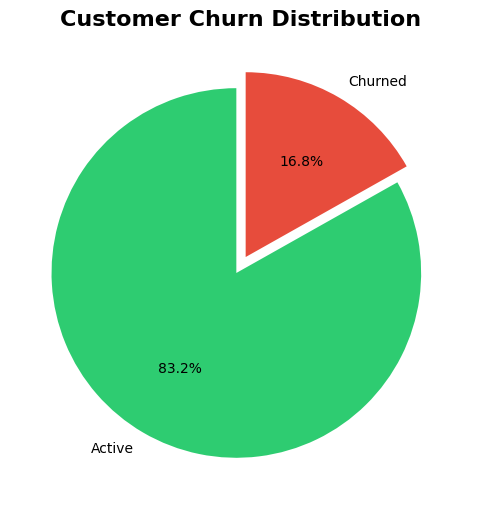

✅ Chart 1 saved!


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\ecommerce_cleaned.csv")
print("✅ Data reloaded! Shape:", df.shape)
+
churn_counts = df['ChurnStatus'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(churn_counts, 
        labels=churn_counts.index,
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        explode=(0.05, 0.05))

plt.title('Customer Churn Distribution', 
          fontsize=16, fontweight='bold')

plt.savefig(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\chart1_churn_distribution.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

In [3]:
print(df.columns.tolist())
print(df['ChurnStatus'].unique())

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'ChurnStatus', 'TenureGroup', 'RiskScore']
['Churned' 'Active']


In [4]:
print(df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'ChurnStatus', 'TenureGroup', 'RiskScore']

First 3 rows:
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     9.0                Phone         1              8.0   
2       50003      1     9.0                Phone         1             30.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  ...  \
0           Debit Card  Female             3.0                         3  ...   
1                  UPI    Male             3.0                         4  ...   
2           Debit Card

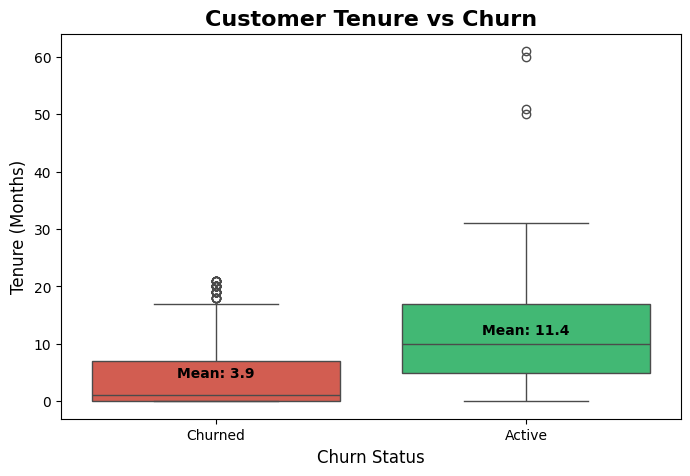

✅ Chart 2 saved!


In [7]:
import os
os.makedirs(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs", exist_ok=True)


plt.figure(figsize=(8, 5))

sns.boxplot(x='ChurnStatus', y='Tenure', data=df,
            hue='ChurnStatus',
            palette={'Churned': '#e74c3c', 'Active': '#2ecc71'},
            legend=False)

plt.title('Customer Tenure vs Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Tenure (Months)', fontsize=12)

for i, status in enumerate(['Churned', 'Active']):
    mean_val = df[df['ChurnStatus'] == status]['Tenure'].mean()
    plt.text(i, mean_val + 0.3, f'Mean: {mean_val:.1f}',
             ha='center', fontsize=10, fontweight='bold')

plt.savefig(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\chart2_tenure_vs_churn.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\ecommerce_cleaned.csv")
os.makedirs(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs", exist_ok=True)

print("✅ Data loaded! Shape:", df.shape)

✅ Data loaded! Shape: (5630, 23)


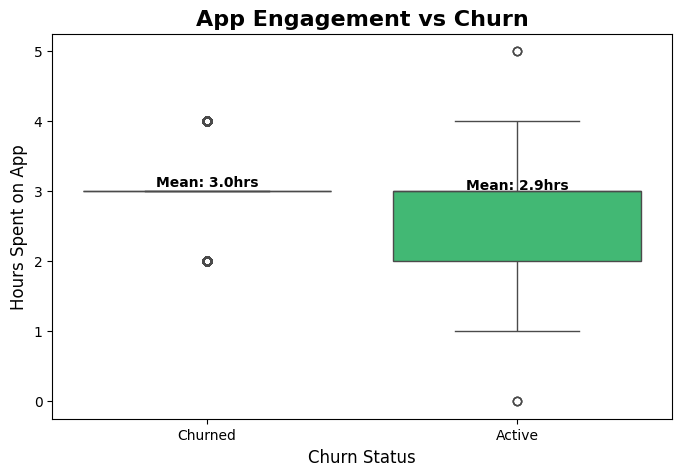

✅ Chart 3 saved!


In [4]:
# Chart 3: App Engagement vs Churn
plt.figure(figsize=(8, 5))

sns.boxplot(x='ChurnStatus', y='HourSpendOnApp', data=df,
            hue='ChurnStatus',
            palette={'Churned': '#e74c3c', 'Active': '#2ecc71'},
            legend=False)

plt.title('App Engagement vs Churn', fontsize=16, fontweight='bold')
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Hours Spent on App', fontsize=12)

for i, status in enumerate(['Churned', 'Active']):
    mean_val = df[df['ChurnStatus'] == status]['HourSpendOnApp'].mean()
    plt.text(i, mean_val + 0.1, f'Mean: {mean_val:.1f}hrs',
             ha='center', fontsize=10, fontweight='bold')

plt.savefig(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\chart3_app_hours_vs_churn.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")
                                    
                                             

FileNotFoundError: [Errno 2] No such file or directory: 'C\\Users\\konin\\Downloads\\Ecommerce-churn\\outputs\\chart4_correlation_heatmap.png'

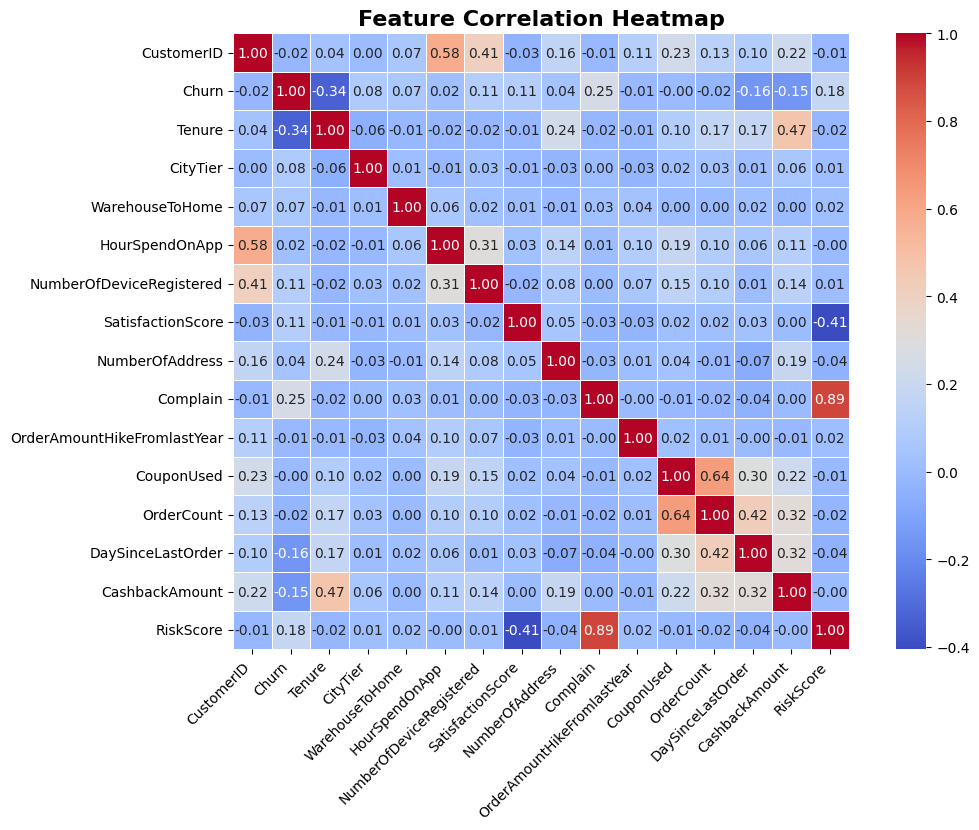

In [8]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            
            square=True,
            linewidths=0.5)

plt.title('Feature Correlation Heatmap', fontsize=16,fontweight='bold')
plt.xticks(rotation=45,ha='right')
plt.yticks(rotation=0)
plt.savefig(r"C\Users\konin\Downloads\Ecommerce-churn\outputs\chart4_correlation_heatmap.png",
            dpi=150,bbox_inches='tight')
plt.show()
print("Chart 4 saves!")




✅ Chart 4 saved!


<Figure size 640x480 with 0 Axes>

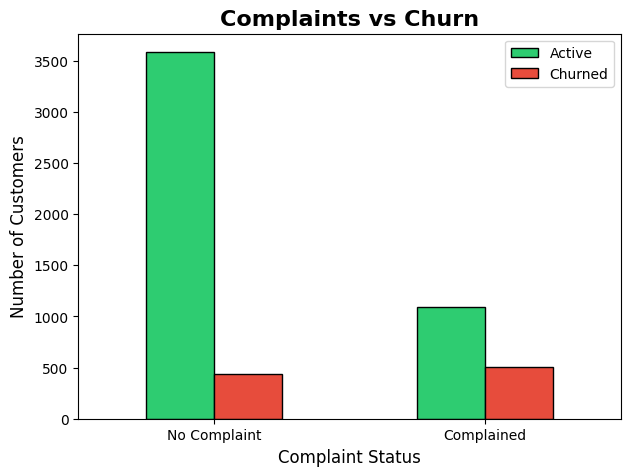

✅ Chart 5 saved!


In [9]:
import os
os.makedirs(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs", exist_ok=True)


plt.savefig(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\chart4_correlation_heatmap.png",
            dpi=150, bbox_inches='tight')
print("✅ Chart 4 saved!")

plt.figure(figsize=(7, 5))

complain_churn = df.groupby(['Complain', 'ChurnStatus']).size().unstack()
complain_churn.index = ['No Complaint', 'Complained']
complain_churn.plot(kind='bar', 
                    color=['#2ecc71', '#e74c3c'],
                    edgecolor='black',
                    ax=plt.gca())

plt.title('Complaints vs Churn', fontsize=16, fontweight='bold')
plt.xlabel('Complaint Status', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Active', 'Churned'])

plt.savefig(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\chart5_complain_vs_churn.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

In [10]:

df.to_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\powerbi_data.csv", 
          index=False)
print("✅ Data exported for Power BI!")

✅ Data exported for Power BI!


In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\ecommerce_cleaned.csv")
print("✅ Loaded! Shape:", df.shape)

✅ Loaded! Shape: (5630, 23)


In [3]:
df['Complain'] = df['Complain'].map({0: 'No Complaint', 1: 'Complained'})
df['CityTier'] = df['CityTier'].map({1: 'Tier 1', 2: 'Tier 2', 3: 'Tier 3'})

df.to_csv(r"C:\Users\konin\Downloads\Ecommerce-churn\outputs\powerbi_data.csv", index=False)
print("✅ Done!")

✅ Done!
